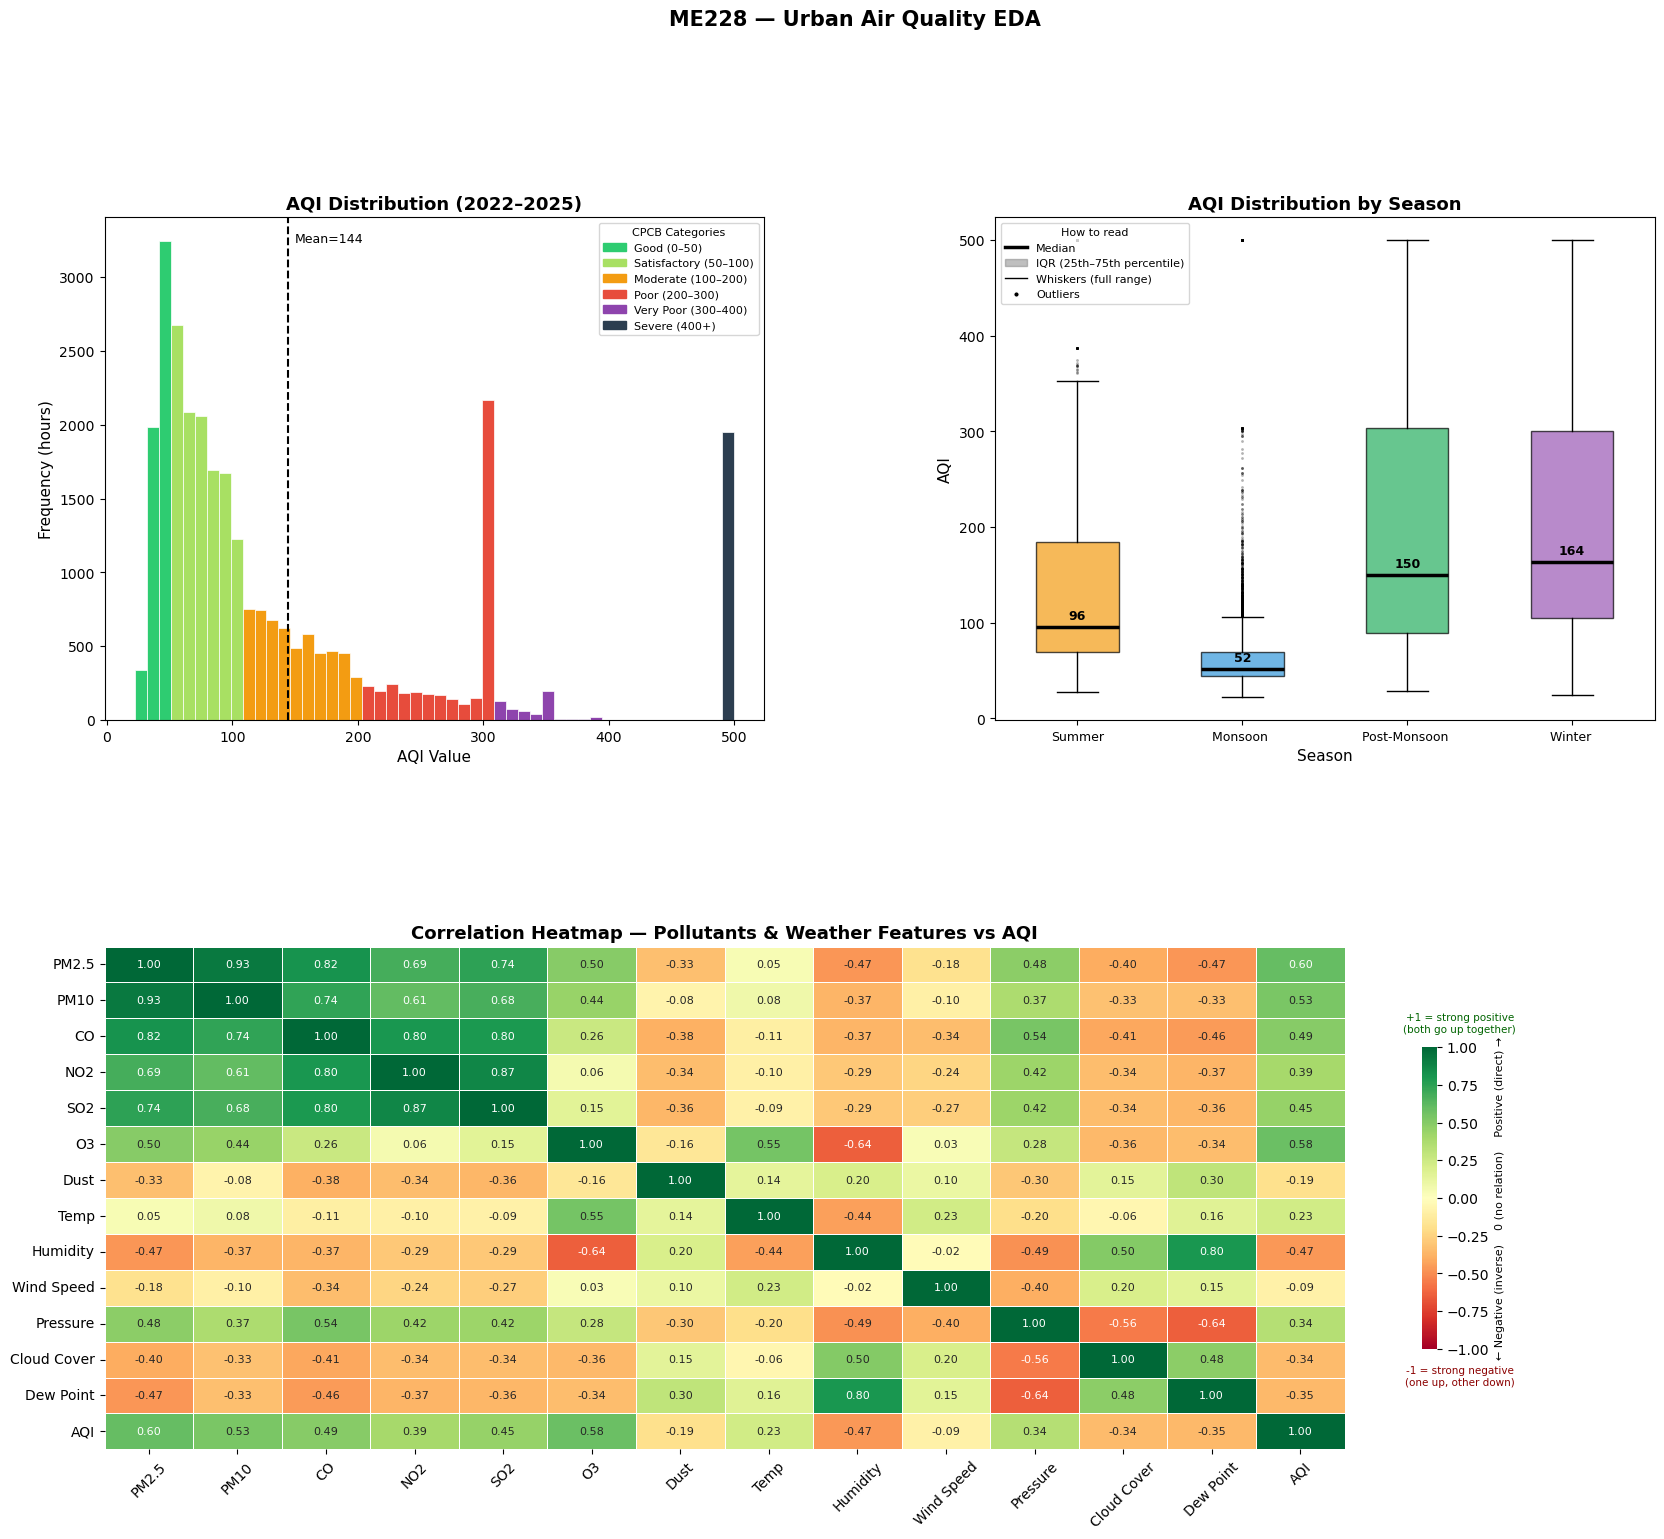

Done! Saved as ME228_EDA_Plots.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

df = pd.read_csv('ME228_Clean_Dataset.csv')

fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: AQI Distribution Histogram ──
ax1 = fig.add_subplot(gs[0, 0])
n, bins, patches = ax1.hist(df['AQI'], bins=50, edgecolor='white', linewidth=0.5)
color_map = [(50,'#2ecc71','Good'),(100,'#a8e063','Satisfactory'),
             (200,'#f39c12','Moderate'),(300,'#e74c3c','Poor'),
             (400,'#8e44ad','Very Poor'),(500,'#2c3e50','Severe')]
for patch, left in zip(patches, bins[:-1]):
    for threshold, color, _ in color_map:
        if left < threshold:
            patch.set_facecolor(color)
            break

ax1.axvline(df['AQI'].mean(), color='black', linestyle='--', linewidth=1.5)
ax1.text(df['AQI'].mean()+5, ax1.get_ylim()[1]*0.95, f'Mean={df["AQI"].mean():.0f}', fontsize=9)

# Legend for color categories
legend_patches = [mpatches.Patch(color=c, label=f'{l} ({t-prev}–{t})'  )
                  for (t,c,l),(prev,_,_) in zip(color_map, [(0,'','')]+color_map[:-1])]
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Good (0–50)'),
    mpatches.Patch(color='#a8e063', label='Satisfactory (50–100)'),
    mpatches.Patch(color='#f39c12', label='Moderate (100–200)'),
    mpatches.Patch(color='#e74c3c', label='Poor (200–300)'),
    mpatches.Patch(color='#8e44ad', label='Very Poor (300–400)'),
    mpatches.Patch(color='#2c3e50', label='Severe (400+)'),
]
ax1.legend(handles=legend_patches, fontsize=8, loc='upper right', title='CPCB Categories', title_fontsize=8)
ax1.set_xlabel('AQI Value', fontsize=11)
ax1.set_ylabel('Frequency (hours)', fontsize=11)
ax1.set_title('AQI Distribution (2022–2025)', fontsize=13, fontweight='bold')

# ── Plot 2: AQI by Season Boxplot ──
ax2 = fig.add_subplot(gs[0, 1])
season_order = ['summer', 'monsoon', 'post_monsoon', 'winter']
season_labels = ['Summer', 'Monsoon ', 'Post-Monsoon ', 'Winter ']
season_colors = ['#f39c12', '#3498db', '#27ae60', '#9b59b6']

box_data = [df[df['season'] == s]['AQI'].values for s in season_order]
bp = ax2.boxplot(box_data, positions=range(4), widths=0.5, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2.5),
                 flierprops=dict(marker='o', markersize=1, alpha=0.3))
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Annotate median values
for i, season in enumerate(season_order):
    med = df[df['season'] == season]['AQI'].median()
    ax2.text(i, med + 8, f'{med:.0f}', ha='center', fontsize=9, fontweight='bold')

ax2.set_xticks(range(4))
ax2.set_xticklabels(season_labels, fontsize=9)
ax2.set_xlabel('Season', fontsize=11)
ax2.set_ylabel('AQI', fontsize=11)
ax2.set_title('AQI Distribution by Season', fontsize=13, fontweight='bold')

# Box plot legend explaining how to read it
box_legend = [
    Line2D([0],[0], color='black', linewidth=2.5, label='Median'),
    mpatches.Patch(color='grey', alpha=0.5, label='IQR (25th–75th percentile)'),
    Line2D([0],[0], color='black', linewidth=1, label='Whiskers (full range)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
           markersize=4, label='Outliers'),
]
ax2.legend(handles=box_legend, fontsize=8, loc='upper left', title='How to read', title_fontsize=8)

# ── Plot 3: Correlation Heatmap ──
ax3 = fig.add_subplot(gs[1, :])
feature_cols = ['pm2_5_ugm3','pm10_ugm3','co_ugm3','no2_ugm3','so2_ugm3','o3_ugm3','dust_ugm3',
                'temp_c','humidity_percent','wind_speed_kmh','pressure_msl_hpa','cloud_cover_percent','dew_point_c']
corr_labels = ['PM2.5','PM10','CO','NO2','SO2','O3','Dust',
               'Temp','Humidity','Wind Speed','Pressure','Cloud Cover','Dew Point']
corr_df = df[feature_cols + ['AQI']].copy()
corr_df.columns = corr_labels + ['AQI']
corr_matrix = corr_df.corr()

sns.heatmap(corr_matrix, ax=ax3, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.6})
ax3.set_title('Correlation Heatmap — Pollutants & Weather Features vs AQI', fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.tick_params(axis='y', rotation=0)

# Colorbar label explanation
cbar = ax3.collections[0].colorbar
cbar.set_label('← Negative (inverse)    0 (no relation)    Positive (direct) →', fontsize=8)
cbar.ax.text(2.5, 1.05, '+1 = strong positive\n(both go up together)', transform=cbar.ax.transAxes,
             fontsize=7.5, ha='center', color='darkgreen')
cbar.ax.text(2.5, -0.12, '-1 = strong negative\n(one up, other down)', transform=cbar.ax.transAxes,
             fontsize=7.5, ha='center', color='darkred')

plt.suptitle('ME228 — Urban Air Quality EDA', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('ME228_EDA_Plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Done! Saved as ME228_EDA_Plots.png')